# Week 9 Phase 1.12 — GPC Kernel Adequacy / Anisotropy Control

A compact teaching notebook reading the frozen outputs; it does not rerun 26,000 GPC fits.

## 1. Why this control is necessary

The scalar physics model H beat the canonical isotropic Matérn-3/2 GPC at low budgets. Here every model sees exactly the same A0 labels, so differences isolate surrogate geometry rather than acquisition.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_12_gpc_kernel_adequacy'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'A0_paths': 100,
 'G0_q20_AULC': 0.8135202205882353,
 'H_q20_AULC': 0.8308134191176471,
 'budgets': [16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80],
 'conduction': 332,
 'folds_per_repeat': 5,
 'initial_B16_matches': 100,
 'keyholes': 73,
 'outer_runs': 100,
 'population': 405,
 'repeat_blocks': 20,
 'sources': {'G0': 'Phase 1.8 Y00/A0', 'H': 'Phase 1.11 MH/A0'},
 'status': 'PASS'}

## 2. Smoothness and anisotropy

RBF is infinitely differentiable; Matérn-3/2 and Matérn-5/2 allow rougher functions. Isotropic kernels share one lengthscale, whereas ARD fits one per standardized coordinate. ARD lengthscales are geometry diagnostics, not causal feature importance.

In [2]:
spec=json.loads((OUT/'kernel_specification.json').read_text()); display(pd.DataFrame(spec['models']).T)

,amplitude_bounds,amplitude_initial,ard,family,input_features,input_scaling,kernel_repr,length_scale_bounds,length_scale_initial,likelihood,n_restarts_optimizer,name,nu,optimizer,primary
G0,"[0.001, 1000.0]",1.0,False,Matern,"[P, VX, LS, ST]",StandardScaler fit on outer training pool inputs,"1**2 * Matern(length_scale=1, nu=1.5)","[0.01, 100.0]",1.0,Bernoulli-logistic Laplace GPC,0,isotropic Matern-3/2,1.5,fmin_l_bfgs_b,False
G1,"[0.001, 1000.0]",1.0,False,RBF,"[P, VX, LS, ST]",StandardScaler fit on outer training pool inputs,1**2 * RBF(length_scale=1),"[0.01, 100.0]",1.0,Bernoulli-logistic Laplace GPC,0,isotropic RBF,None,fmin_l_bfgs_b,False
G2,"[0.001, 1000.0]",1.0,True,RBF,"[P, VX, LS, ST]",StandardScaler fit on outer training pool inputs,"1**2 * RBF(length_scale=[1, 1, 1, 1])","[0.01, 100.0]","[1.0, 1.0, 1.0, 1.0]",Bernoulli-logistic Laplace GPC,0,ARD RBF,None,fmin_l_bfgs_b,False
G3,"[0.001, 1000.0]",1.0,True,Matern,"[P, VX, LS, ST]",StandardScaler fit on outer training pool inputs,"1**2 * Matern(length_scale=[1, 1, 1, 1], nu=1.5)","[0.01, 100.0]","[1.0, 1.0, 1.0, 1.0]",Bernoulli-logistic Laplace GPC,0,ARD Matern-3/2,1.5,fmin_l_bfgs_b,True
G4,"[0.001, 1000.0]",1.0,False,Matern,"[P, VX, LS, ST]",StandardScaler fit on outer training pool inputs,"1**2 * Matern(length_scale=1, nu=2.5)","[0.01, 100.0]",1.0,Bernoulli-logistic Laplace GPC,0,isotropic Matern-5/2,2.5,fmin_l_bfgs_b,False


## 3. Frozen protocol

The 100 outer runs, shared B16 designs, A0 prefixes, B1-q20/q30 definitions, and 16–80 grid are unchanged. Week 5 was regression on a different target; it motivates kernel conventions but does not answer this classification question.

,model,subset,mean_AULC,ci_lower,ci_upper
0,G0,B1_q20,0.813520,0.806820,0.820382
1,G0,B1_q30,0.866116,0.861637,0.870675
2,G1,B1_q20,0.812822,0.806438,0.819297
3,G1,B1_q30,0.864216,0.859890,0.868547
4,G2,B1_q20,0.822619,0.814669,0.830239
5,G2,B1_q30,0.866328,0.859009,0.873385
6,G3,B1_q20,0.826595,0.818943,0.834260
7,G3,B1_q30,0.869675,0.862365,0.876487
8,G4,B1_q20,0.812160,0.805404,0.819384
9,G4,B1_q30,0.864266,0.859984,0.868778


,contrast,subset,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws
0,G3-G0,B1_q20,0.013074,0.005624,0.020216,16,0,4,10000
1,G3-H,B1_q20,-0.004219,-0.011287,0.002973,8,0,12,10000
2,G1-G0,B1_q20,-0.000699,-0.003663,0.002275,9,0,11,10000
3,G2-G1,B1_q20,0.009798,0.000694,0.018139,13,0,7,10000
4,G4-G0,B1_q20,-0.001360,-0.003897,0.001112,8,0,12,10000
5,G2-H,B1_q20,-0.008194,-0.015391,-0.000896,7,0,13,10000
6,G1-H,B1_q20,-0.017992,-0.023884,-0.012114,2,0,18,10000
7,G4-H,B1_q20,-0.018653,-0.025028,-0.012082,2,0,18,10000


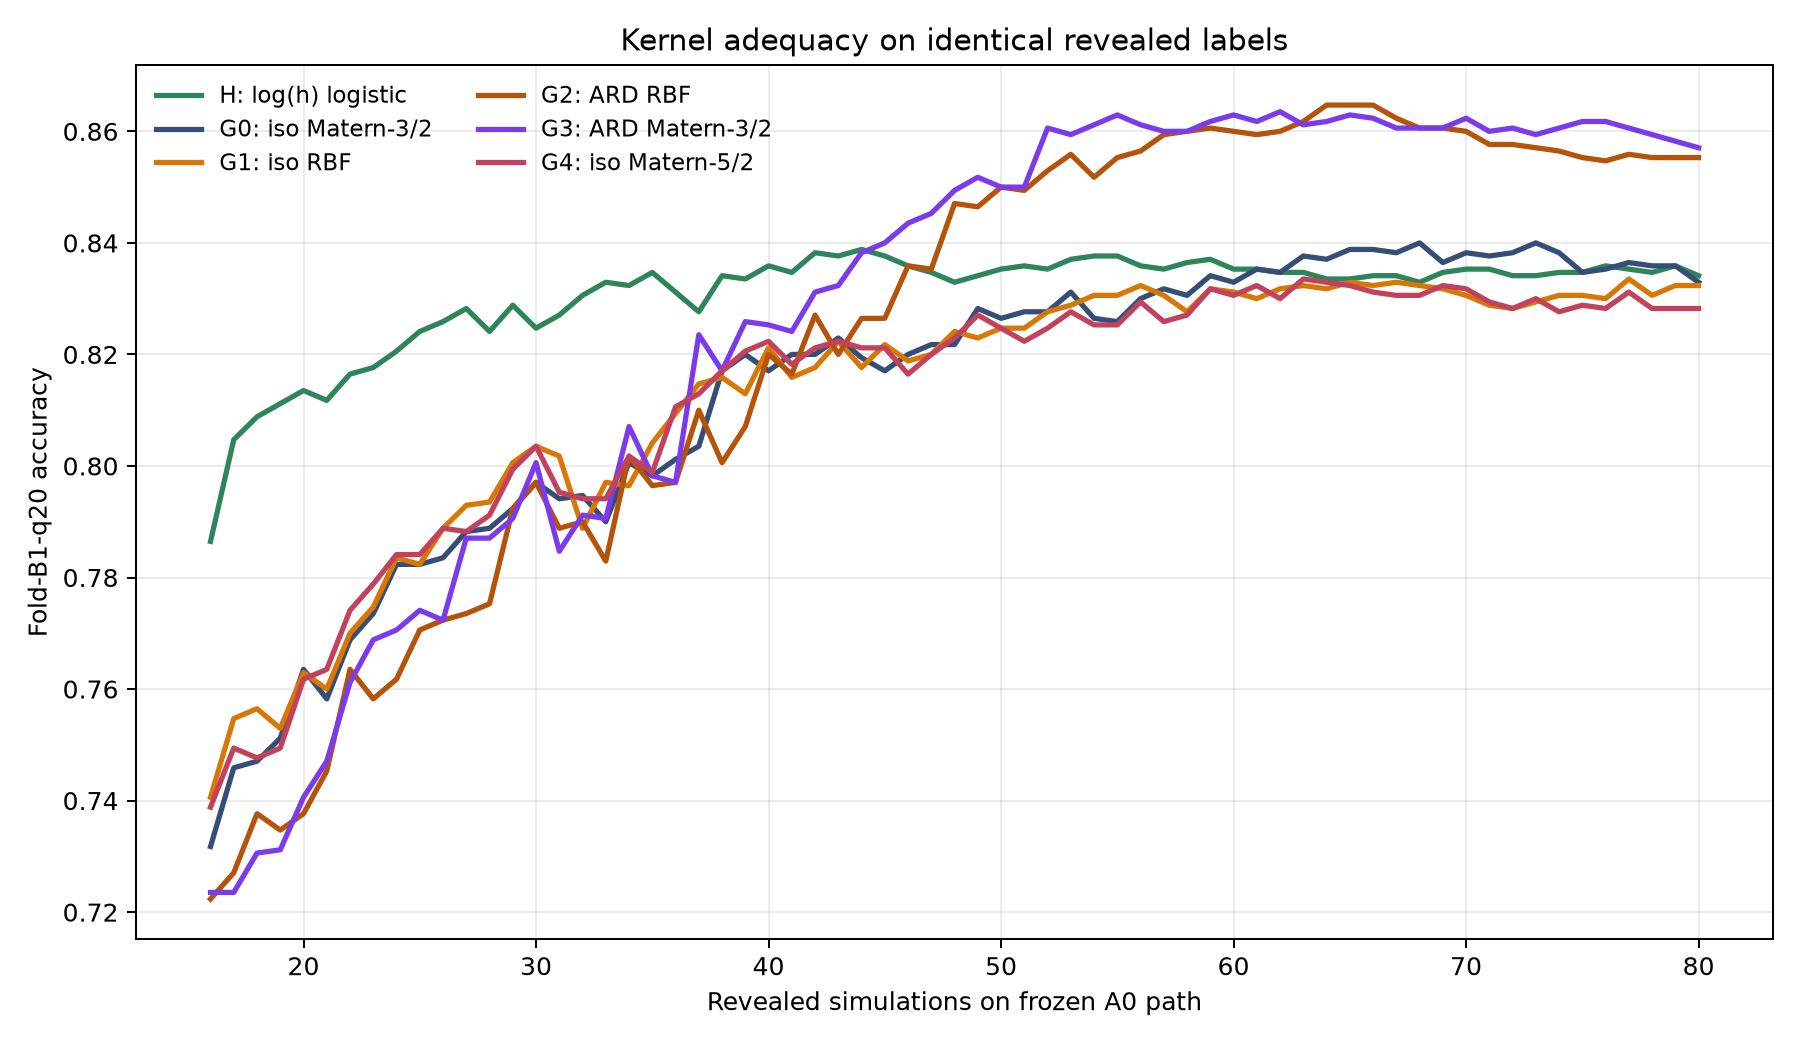

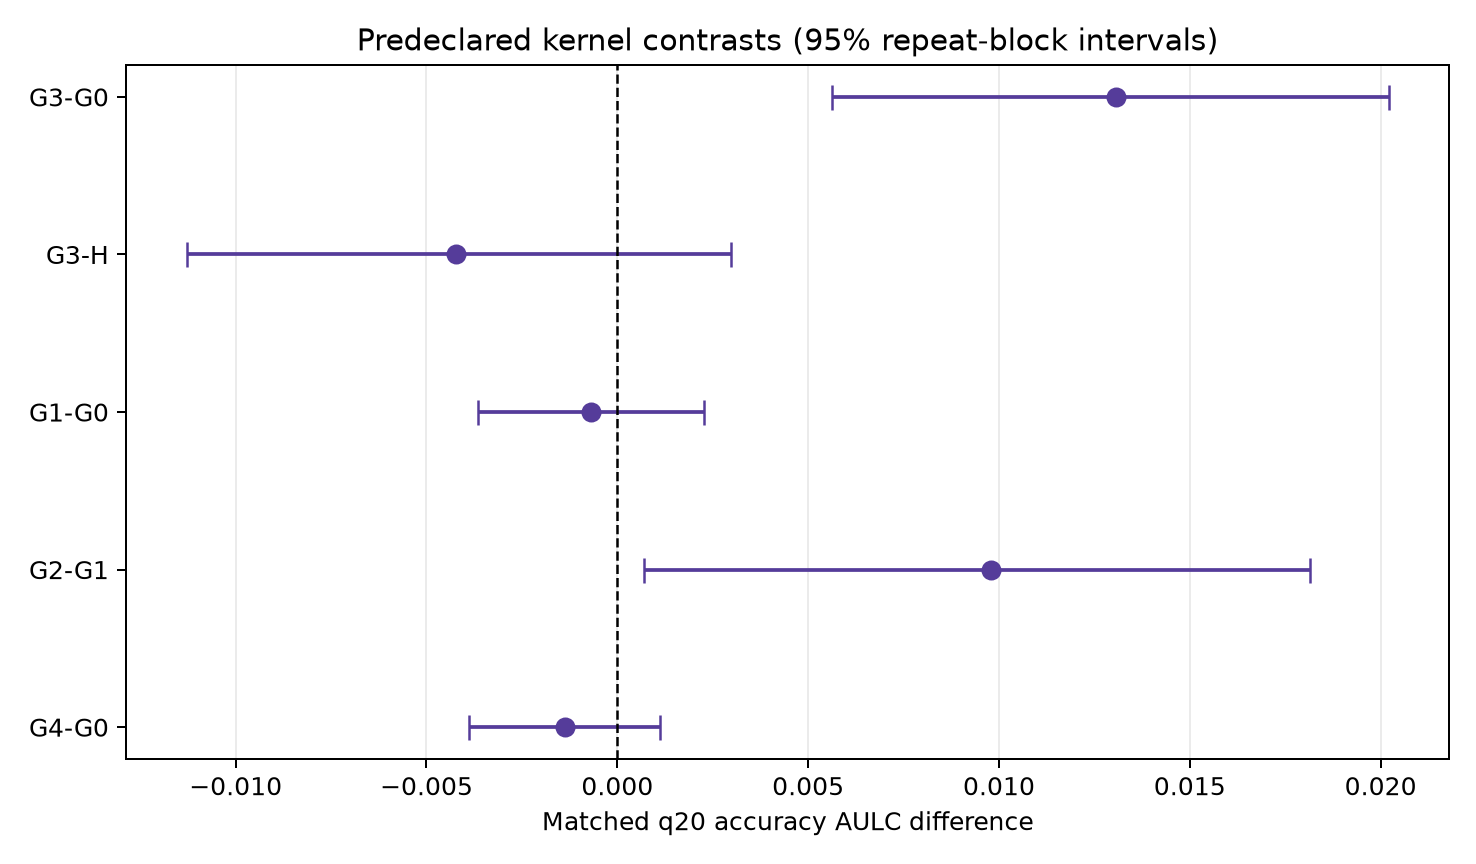

In [3]:
summary=pd.read_csv(OUT/'model_summary.csv'); contrasts=pd.read_csv(OUT/'paired_contrasts.csv'); display(summary); display(contrasts[contrasts.subset.eq('B1_q20')]); display(Image(filename=str(OUT/'figures'/'01_q20_learning_curves.png'))); display(Image(filename=str(OUT/'figures'/'02_q20_aulc_contrasts.png')))

## 4. B16 and later checkpoints

B16 is the clean low-data comparison because all models receive the same initial design.

In [4]:
display(pd.read_csv(OUT/'budget16_summary.csv')); display(pd.read_csv(OUT/'budget16_hard_disagreements.csv')); display(pd.read_csv(OUT/'checkpoint40_80_summary.csv'))

,model,subset,budget,metric,mean,ci_lower,ci_upper
0,G0,B1_q20,16,accuracy,0.731765,0.714118,0.750000
1,G0,B1_q20,16,balanced_accuracy,0.686194,0.659696,0.713351
2,G0,B1_q20,16,keyhole_recall,0.497492,0.431626,0.564605
3,G0,B1_q20,16,conduction_recall,0.874897,0.851111,0.899834
4,G0,B1_q20,16,false_negative,3.280000,2.880000,3.700000
5,G0,B1_q20,16,false_positive,1.280000,1.040000,1.530000
6,G1,B1_q20,16,accuracy,0.740588,0.723529,0.758824
7,G1,B1_q20,16,balanced_accuracy,0.695890,0.669671,0.722732
8,G1,B1_q20,16,keyhole_recall,0.510365,0.443641,0.575774
9,G1,B1_q20,16,conduction_recall,0.881415,0.856439,0.906551


,pair,category,count,scope
0,H_vs_G0,same_decision,1399,100 matched outer-fold q20 test predictions at...
1,H_vs_G0,different_decision,301,100 matched outer-fold q20 test predictions at...
2,H_vs_G0,H_only_correct,197,100 matched outer-fold q20 test predictions at...
3,H_vs_G0,G0_only_correct,104,100 matched outer-fold q20 test predictions at...
4,H_vs_G0,both_correct,1140,100 matched outer-fold q20 test predictions at...
5,H_vs_G0,both_wrong,259,100 matched outer-fold q20 test predictions at...
6,H_vs_G3,same_decision,1303,100 matched outer-fold q20 test predictions at...
7,H_vs_G3,different_decision,397,100 matched outer-fold q20 test predictions at...
8,H_vs_G3,H_only_correct,252,100 matched outer-fold q20 test predictions at...
9,H_vs_G3,G3_only_correct,145,100 matched outer-fold q20 test predictions at...


,model,subset,budget,metric,mean,ci_lower,ci_upper
0,G0,B1_q20,40,accuracy,0.817059,0.805882,0.827647
1,G0,B1_q20,40,balanced_accuracy,0.797113,0.783520,0.809169
2,G0,B1_q20,40,keyhole_recall,0.711044,0.683178,0.736969
3,G0,B1_q20,40,conduction_recall,0.883181,0.867234,0.898065
4,G0,B1_q20,80,accuracy,0.832941,0.821176,0.844118
5,G0,B1_q20,80,balanced_accuracy,0.813096,0.800889,0.824553
6,G0,B1_q20,80,keyhole_recall,0.732381,0.709550,0.754651
7,G0,B1_q20,80,conduction_recall,0.893812,0.881370,0.906685
8,G1,B1_q20,40,accuracy,0.821176,0.807647,0.834118
9,G1,B1_q20,40,balanced_accuracy,0.800769,0.787498,0.813506


## 5. ARD stability and bound behavior

Lengthscales are reported in standardized input space. Values at bounds signal weakly resolved geometry, not physical irrelevance.

,model,budget,parameter,median,q1,q3,space
0,G2,16,l_P,2.029468,1.777420,2.436542,standardized outer-training-pool inputs
1,G2,16,l_VX,13.204071,3.673319,100.000000,standardized outer-training-pool inputs
2,G2,16,l_LS,9.305063,2.893229,100.000000,standardized outer-training-pool inputs
3,G2,16,l_ST,100.000000,100.000000,100.000000,standardized outer-training-pool inputs
4,G2,16,anisotropy_ratio,53.391963,44.989217,89.531771,standardized outer-training-pool inputs
5,G2,40,l_P,2.505419,1.864873,3.034362,standardized outer-training-pool inputs
6,G2,40,l_VX,3.449842,2.592582,4.286584,standardized outer-training-pool inputs
7,G2,40,l_LS,2.610758,2.166179,3.184149,standardized outer-training-pool inputs
8,G2,40,l_ST,100.000000,100.000000,100.000000,standardized outer-training-pool inputs
9,G2,40,anisotropy_ratio,44.100401,34.068141,62.392938,standardized outer-training-pool inputs


,model,diagnostic,fit_count,count,rate
0,G1,amplitude_lower_bound_hit,6500,8,0.001231
1,G1,amplitude_upper_bound_hit,6500,666,0.102462
2,G1,any_length_lower_bound_hit,6500,2,0.000308
3,G1,any_length_upper_bound_hit,6500,1,0.000154
4,G1,any_length_bound_hit,6500,3,0.000462
5,G1,optimizer_warning,6500,674,0.103692
6,G1,l_P_lower_bound_hit,6500,2,0.000308
7,G1,l_P_upper_bound_hit,6500,1,0.000154
8,G1,l_VX_lower_bound_hit,6500,2,0.000308
9,G1,l_VX_upper_bound_hit,6500,1,0.000154


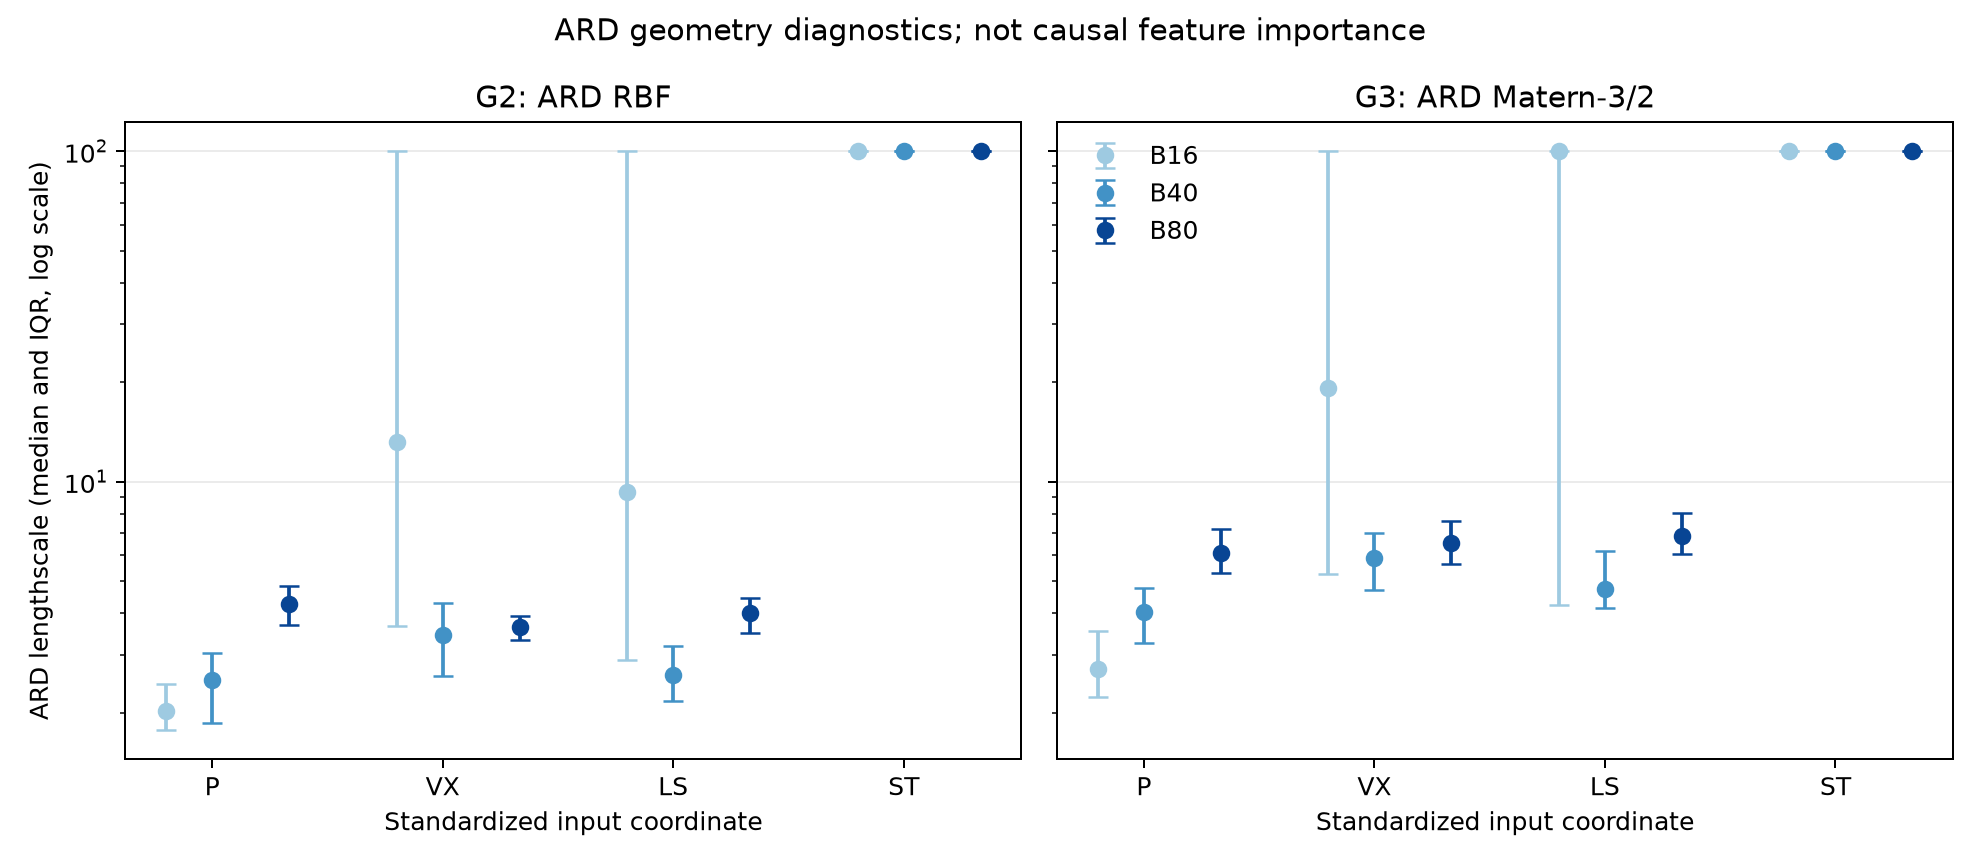

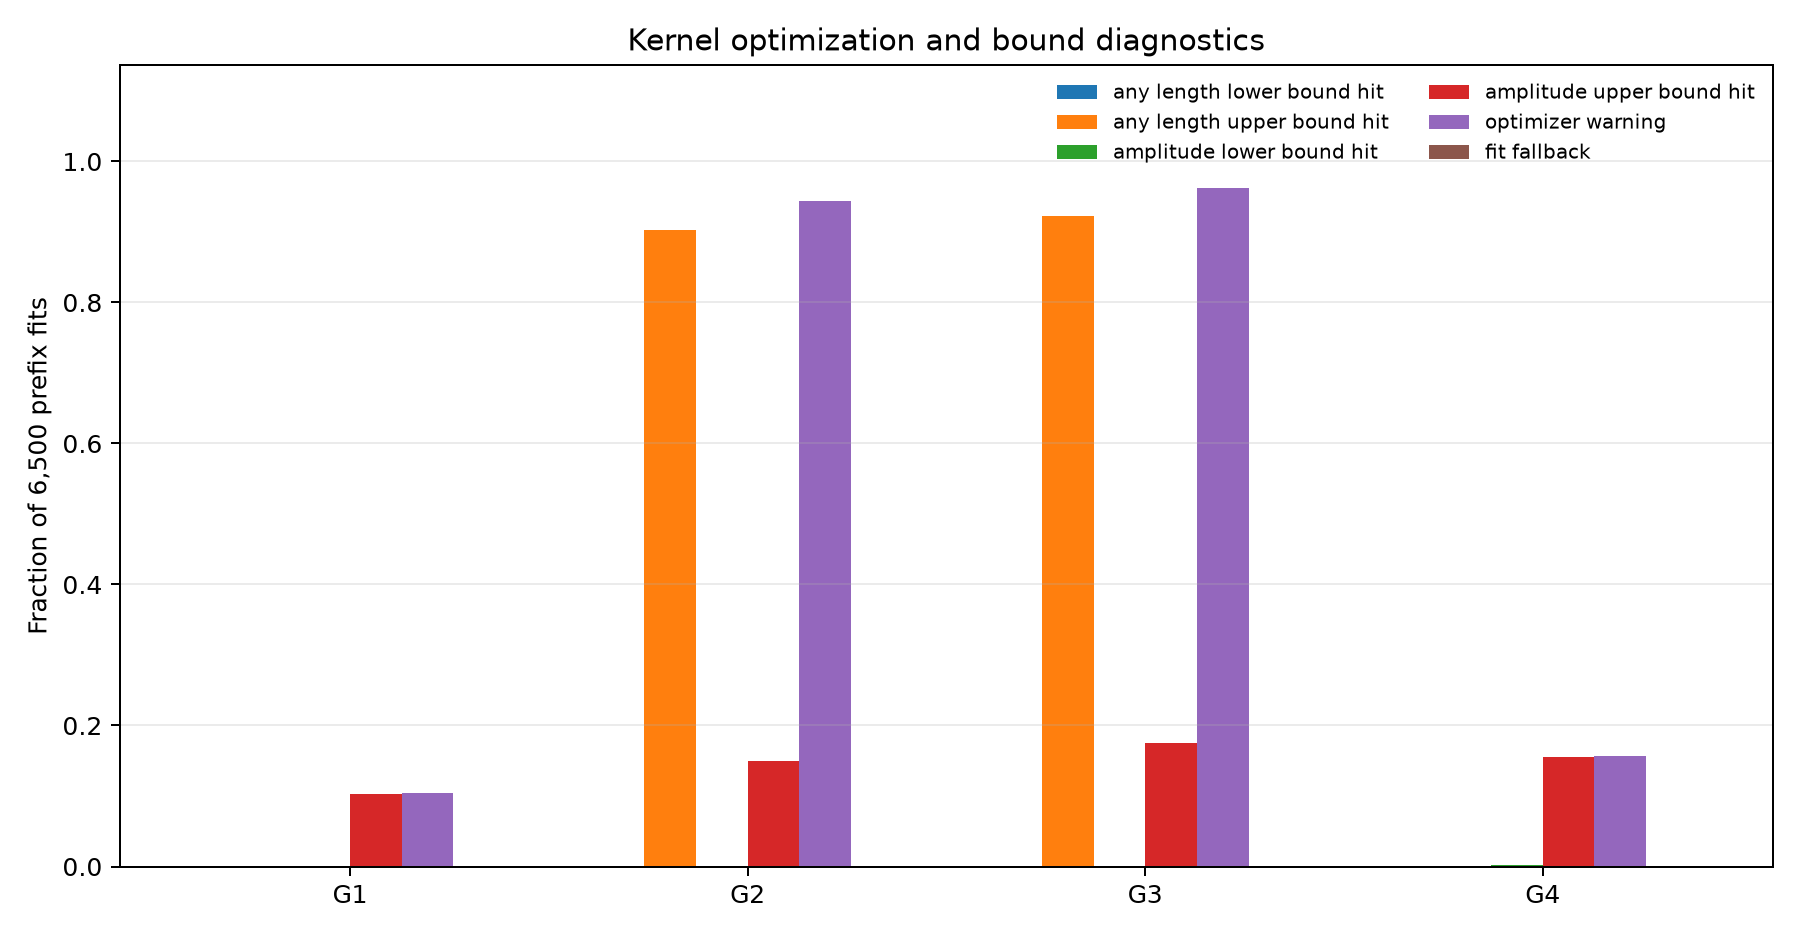

In [5]:
display(pd.read_csv(OUT/'ard_lengthscale_summary.csv')); display(pd.read_csv(OUT/'bound_hit_summary.csv')); display(Image(filename=str(OUT/'figures'/'03_ard_lengthscales.png'))); display(Image(filename=str(OUT/'figures'/'04_kernel_fit_diagnostics.png')))

## 6. Best fixed kernel versus an oracle

The highest mean fixed GPC is descriptive. The oracle chooses a kernel separately per repeat and is intentionally non-deployable.

In [6]:
display(pd.read_csv(OUT/'oracle_gpc_diagnostic.csv')); display(Markdown((OUT/'SUPERVISOR_PHASE1_12_ONE_PAGE.md').read_text()))

,repeat,H_AULC,oracle_GPC_AULC,H_minus_oracle,oracle_selected_model,diagnostic_status
0,1,0.826838,0.835018,-0.008180,G2,NON_DEPLOYABLE_REPEATWISE_ORACLE
1,2,0.823621,0.817555,0.006066,G0,NON_DEPLOYABLE_REPEATWISE_ORACLE
2,3,0.828952,0.823805,0.005147,G0,NON_DEPLOYABLE_REPEATWISE_ORACLE
3,4,0.818934,0.800000,0.018934,G2,NON_DEPLOYABLE_REPEATWISE_ORACLE
4,5,0.814706,0.842831,-0.028125,G3,NON_DEPLOYABLE_REPEATWISE_ORACLE
5,6,0.838603,0.860110,-0.021507,G3,NON_DEPLOYABLE_REPEATWISE_ORACLE
6,7,0.836305,0.837132,-0.000827,G2,NON_DEPLOYABLE_REPEATWISE_ORACLE
7,8,0.835662,0.825643,0.010018,G2,NON_DEPLOYABLE_REPEATWISE_ORACLE
8,9,0.850919,0.840717,0.010202,G3,NON_DEPLOYABLE_REPEATWISE_ORACLE
9,10,0.818934,0.836857,-0.017923,G2,NON_DEPLOYABLE_REPEATWISE_ORACLE


# Supervisor Phase 1.12 â€” one page

**Decision:** KERNEL_GAP_CLOSED

- q20 AULC H/G0/G1/G2/G3/G4: 0.8308 / 0.8135 / 0.8128 / 0.8226 / 0.8266 / 0.8122.
- Primary ARD MatÃ©rn-3/2 gain over isotropic MatÃ©rn-3/2: +0.0131 [+0.0056, +0.0202].
- ARD MatÃ©rn-3/2 versus h-only: -0.0042 [-0.0113, +0.0030].
- B16 q20 accuracy H/G0/G3: 0.786 / 0.732 / 0.724.
- B16 q20 Keyhole recall H/G0/G3: 0.719 / 0.497 / 0.525.
- q30 G3-G0: +0.0036 [-0.0042, +0.0103].
- Descriptive best fixed GPC: G3; no post-hoc winner CI is promoted.
- Future h + ARD discrepancy GP: YES.

All models saw the same revealed labels. ARD lengthscales describe fitted standardized geometry only; boundary hits and optimizer warnings are disclosed. No acquisition claim is made.


## 7. Limits

This phase tests held-out boundary prediction on a frozen simulator benchmark. It does not establish acquisition superiority, causal variable importance, or external validity.